### Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
import mlflow
import logging
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.autograd import Variable
from torch.utils.tensorboard import SummaryWriter
from torch import optim
from src.org_unet_parts import *
from dataloader import ACDCDataset
from utils.dice_score import dice_loss, dice_coeff, weighted_dice_loss
from utils.evaluate import evaluate
from utils.utils import EarlyStopping
%matplotlib inline

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.21 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [2]:
exp_run_id = f'multi_scale_res_unet_with_feedback_img_slices_with_ratios_v4_multi_class{datetime.now().strftime("%Y%m%d%H%M%S")}'
log_file_name = f'./logs/{exp_run_id}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [4]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-segmentation-of-ventricular-structures-and-myocardium")

2024/11/27 14:11:10 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/1301949192404675', creation_time=1726678925784, experiment_id='1301949192404675', last_update_time=1732654186720, lifecycle_stage='active', name='/cmri-segmentation-of-ventricular-structures-and-myocardium', tags={'mlflow.experiment.sourceName': '/cmri-segmentation-of-ventricular-structures-and-myocardium',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [5]:
dir_checkpoint = Path('./models/checkpoints/multi_scale_res_unet_with_feedback_img_slices_with_ratios_v4-vaunted-shrew-599/')

epochs = 100
batch_size = 8
lr = 5e-5
scale = 1
amp = False
class_weights = torch.tensor([0.3, 0.4, 0.3]).to(device=device)

### Data Loading

In [6]:
root_dir = r'../data/ACDC/img_slices_with_ratios_v4/'
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training')  # crop_resize_ind=True, margin=0.05
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation')
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing')

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

Loaded 16000 training images
Loaded 2000 validation images
Loaded 2000 testing images


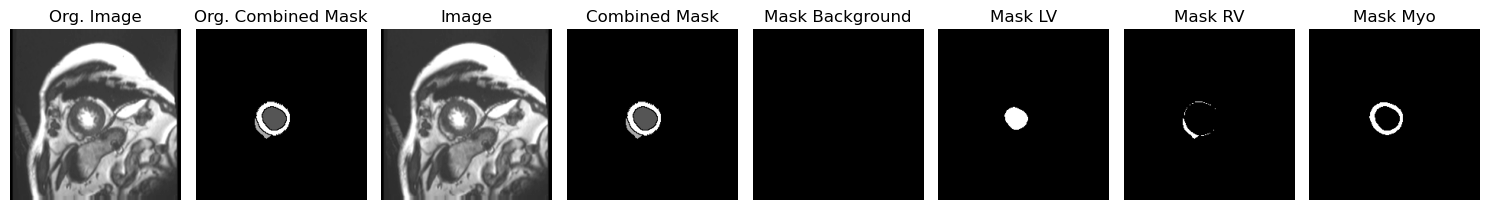

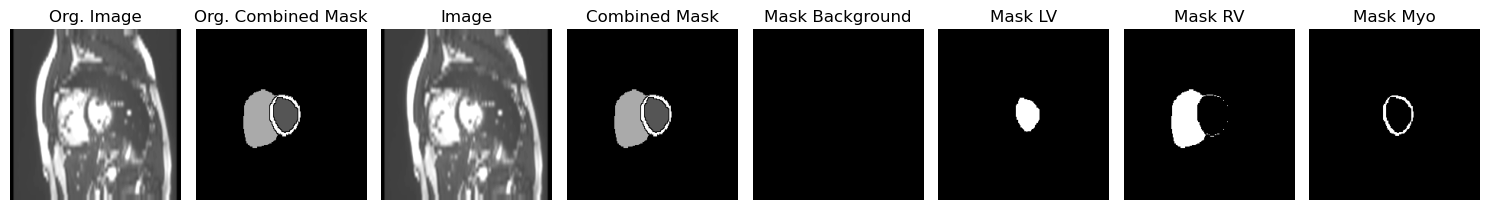

In [7]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break

    # Extract data from the sample
    org_image = sample['org_image'][i].squeeze().numpy()
    image = sample['image'][i].squeeze().numpy()
    org_msk_all = sample['org_masks_all'][i].squeeze().numpy()
    msk_all = sample['masks_all'][i].squeeze().numpy()
    msk_bkg = sample['masks'][i][0].squeeze().numpy()
    msk_lv = sample['masks'][i][1].squeeze().numpy()
    msk_rv = sample['masks'][i][2].squeeze().numpy()
    msk_myo = sample['masks'][i][3].squeeze().numpy()

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 8, figsize=(15, 5))

    # Plot the image and masks
    axes[0].imshow(org_image, cmap='gray')
    axes[0].set_title('Org. Image')
    axes[0].axis('off')
    
    axes[1].imshow(org_msk_all, cmap='gray')
    axes[1].set_title('Org. Combined Mask')
    axes[1].axis('off')
    
    axes[2].imshow(image, cmap='gray')
    axes[2].set_title('Image')
    axes[2].axis('off')
    
    axes[3].imshow(msk_all, cmap='gray')
    axes[3].set_title('Combined Mask')
    axes[3].axis('off')
    
    axes[4].imshow(msk_bkg, cmap='gray')
    axes[4].set_title('Mask Background')
    axes[4].axis('off')
    
    axes[5].imshow(msk_lv, cmap='gray')
    axes[5].set_title('Mask LV')
    axes[5].axis('off')
    
    axes[6].imshow(msk_rv, cmap='gray')
    axes[6].set_title('Mask RV')
    axes[6].axis('off')
    
    axes[7].imshow(msk_myo, cmap='gray')
    axes[7].set_title('Mask Myo')
    axes[7].axis('off')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

#### Multi-Scale UNet

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class MultiScaleUNet(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=False):
        super(MultiScaleUNet, self).__init__()
        self.n_channels = in_channels
        self.n_classes = out_channels
        self.bilinear = bilinear

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64 + in_channels, 128)
        self.enc3 = DoubleConv(128 + in_channels, 256)
        self.enc4 = DoubleConv(256 + in_channels, 512)

        # Bottleneck
        self.bottleneck = DoubleConv(512 + in_channels, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(512 * 2, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256 * 2, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128 * 2, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64 * 2, 64)

        # Output layer
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Multi-scale inputs for each encoder layer
        # Downsample input image to create multi-scale versions
        x1 = x  # Original size
        x2 = F.interpolate(x, scale_factor=0.5, mode='bilinear', align_corners=False)  # Half size
        x3 = F.interpolate(x, scale_factor=0.25, mode='bilinear', align_corners=False)  # Quarter size
        x4 = F.interpolate(x, scale_factor=0.125, mode='bilinear', align_corners=False)  # One-eighth size

        # Encoder
        enc1 = self.enc1(x1)
        enc2 = self.enc2(torch.cat([F.max_pool2d(enc1, 2), x2], dim=1))
        enc3 = self.enc3(torch.cat([F.max_pool2d(enc2, 2), x3], dim=1))
        enc4 = self.enc4(torch.cat([F.max_pool2d(enc3, 2), x4], dim=1))

        # Bottleneck
        x4_pooled = F.adaptive_max_pool2d(x4, output_size=F.max_pool2d(enc4, 2).shape[2:])
        bottleneck = self.bottleneck(torch.cat([F.max_pool2d(enc4, 2), x4_pooled], dim=1))

        # Decoder
        up4 = self.upconv4(bottleneck)
        dec4 = self.dec4(torch.cat([up4, enc4], dim=1))

        up3 = self.upconv3(dec4)
        dec3 = self.dec3(torch.cat([up3, enc3], dim=1))

        up2 = self.upconv2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc2], dim=1))

        up1 = self.upconv1(dec2)
        dec1 = self.dec1(torch.cat([up1, enc1], dim=1))

        # Output
        out = self.out_conv(dec1)
        return out

### Multi-Scale ResUNet

In [ ]:
# Residual Block
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # Skip connection
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        
    def forward(self, x):
        identity = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += identity
        return self.relu(out)

# Downsampling Block
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        self.res_block = ResidualBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        out = self.res_block(x)
        pooled = self.pool(out)
        return out, pooled

# Upsampling Block
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.res_block = ResidualBlock(out_channels * 2, out_channels)
        
    def forward(self, x, skip_connection):
        x = self.up(x)
        x = torch.cat((x, skip_connection), dim=1)
        return self.res_block(x)

# Multi-Resolution Residual UNet
class MultiResolutionResidualUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, bilinear=False):
        super(MultiResolutionResidualUNet, self).__init__()
        self.n_channels = in_channels
        self.n_classes = num_classes
        self.bilinear = bilinear
        
        # Encoding layers
        self.down1 = DownBlock(in_channels, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)
        
        # Bottleneck
        self.bottleneck = ResidualBlock(512, 1024)
        
        # Decoding layers
        self.up4 = UpBlock(1024, 512)
        self.up3 = UpBlock(512, 256)
        self.up2 = UpBlock(256, 128)
        self.up1 = UpBlock(128, 64)
        
        # Multi-resolution inputs
        self.downsample_half = nn.AvgPool2d(2)
        self.downsample_quarter = nn.AvgPool2d(4)
        
        # Output layer
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)
        
    def forward(self, x):
        # Multi-resolution inputs
        x_half = self.downsample_half(x)
        x_quarter = self.downsample_quarter(x)
        
        # Encode full-resolution
        skip1_full, x_full = self.down1(x)
        skip2_full, x_full = self.down2(x_full)
        skip3_full, x_full = self.down3(x_full)
        skip4_full, x_full = self.down4(x_full)
        
        # Encode half-resolution
        _, x_half = self.down1(x_half)
        _, x_half = self.down2(x_half)
        _, x_half = self.down3(x_half)
        _, x_half = self.down4(x_half)
        
        # Encode quarter-resolution
        _, x_quarter = self.down1(x_quarter)
        _, x_quarter = self.down2(x_quarter)
        _, x_quarter = self.down3(x_quarter)
        _, x_quarter = self.down4(x_quarter)
        
        # Combine multi-resolution features
        x_full += F.interpolate(x_half, scale_factor=2, mode='bilinear', align_corners=True)
        x_full += F.interpolate(x_quarter, scale_factor=4, mode='bilinear', align_corners=True)
        
        # Bottleneck
        x = self.bottleneck(x_full)
        
        # Decode
        x = self.up4(x, skip4_full)
        x = self.up3(x, skip3_full)
        x = self.up2(x, skip2_full)
        x = self.up1(x, skip1_full)
        
        # Output segmentation map
        return self.output_conv(x)

#### Multi-Scale Attention UNet (skip conns)

In [ ]:
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, in_channels, gating_channels, inter_channels):
        super(AttentionBlock, self).__init__()
        # Convolution layer for the gating signal
        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_channels)
        )
        
        # Convolution layer for the skip connection
        self.W_x = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_channels)
        )
        
        # Psi layer to generate the attention map
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x, g):
        # Apply gating signal and skip connection transformations
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # Add and apply ReLU activation
        psi = self.relu(g1 + x1)
        # Generate attention map
        psi = self.psi(psi)
        # Apply attention to the input feature map
        return x * psi

# Downsampling Block
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        # Residual block with two convolutional layers
        self.res_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # Max pooling for downsampling
        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        # Apply residual block
        out = self.res_block(x)
        # Apply max pooling to get the downsampled output
        pooled = self.pool(out)
        return out, pooled

# Upsampling Block with Attention
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()
        # Transposed convolution for upsampling
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Attention block to refine skip connection features
        self.attention = AttentionBlock(out_channels, in_channels // 2, in_channels // 4)
        # Convolutional layers after concatenating skip connection
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x, skip_connection):
        # Upsample the input
        x = self.up(x)
        # Apply attention to the skip connection
        skip_connection = self.attention(skip_connection, x)
        # Concatenate upsampled input and skip connection
        x = torch.cat((x, skip_connection), dim=1)
        # Apply convolutional layers
        return self.conv(x)

# Multi-Resolution Attention UNet
class MultiResolutionAttentionUNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, bilinear=False):
        super(MultiResolutionAttentionUNet, self).__init__()
        self.n_channels = in_channels
        self.n_classes = num_classes
        self.bilinear = bilinear
        
        # Encoding layers
        self.down1 = DownBlock(in_channels, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)
        
        # Bottleneck layer
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        
        # Decoding layers with attention blocks
        self.up4 = UpBlock(1024, 512)
        self.up3 = UpBlock(512, 256)
        self.up2 = UpBlock(256, 128)
        self.up1 = UpBlock(128, 64)
        
        # Multi-resolution inputs
        self.downsample_half = nn.AvgPool2d(2)  # Downsample input to half resolution
        self.downsample_quarter = nn.AvgPool2d(4)  # Downsample input to quarter resolution
        
        # Output layer to get final segmentation map
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)
        
    def forward(self, x):
        # Generate multi-resolution inputs
        x_half = self.downsample_half(x)
        x_quarter = self.downsample_quarter(x)
        
        # Encode full-resolution input
        skip1_full, x_full = self.down1(x)
        skip2_full, x_full = self.down2(x_full)
        skip3_full, x_full = self.down3(x_full)
        skip4_full, x_full = self.down4(x_full)
        
        # Encode half-resolution input
        _, x_half = self.down1(x_half)
        _, x_half = self.down2(x_half)
        _, x_half = self.down3(x_half)
        _, x_half = self.down4(x_half)
        
        # Encode quarter-resolution input
        _, x_quarter = self.down1(x_quarter)
        _, x_quarter = self.down2(x_quarter)
        _, x_quarter = self.down3(x_quarter)
        _, x_quarter = self.down4(x_quarter)
        
        # Combine multi-resolution features with alignment
        x_full_size = x_full.shape[-2:]  # Get H, W of full resolution

        # Upsample and align half-resolution features
        x_half_upsampled = F.interpolate(x_half, size=x_full_size, mode='bilinear', align_corners=True)

        # Upsample and align quarter-resolution features
        x_quarter_upsampled = F.interpolate(x_quarter, size=x_full_size, mode='bilinear', align_corners=True)

        # Combine all three resolutions
        x_full += x_half_upsampled
        x_full += x_quarter_upsampled
        
        # Apply bottleneck layer
        x = self.bottleneck(x_full)
        
        # Decode using skip connections and attention blocks
        x = self.up4(x, skip4_full)
        x = self.up3(x, skip3_full)
        x = self.up2(x, skip2_full)
        x = self.up1(x, skip1_full)
        
        # Generate output segmentation map
        return self.output_conv(x)

#### Multi-Scale Attention UNet (skip conns and bottleneck)

In [8]:
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, in_channels, gating_channels, inter_channels):
        super(AttentionBlock, self).__init__()
        # Convolution layer for the gating signal
        self.W_g = nn.Sequential(
            nn.Conv2d(gating_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_channels)
        )
        
        # Convolution layer for the skip connection
        self.W_x = nn.Sequential(
            nn.Conv2d(in_channels, inter_channels, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(inter_channels)
        )
        
        # Psi layer to generate the attention map
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x, g):
        # Apply gating signal and skip connection transformations
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        # Add and apply ReLU activation
        psi = self.relu(g1 + x1)
        # Generate attention map
        psi = self.psi(psi)
        # Apply attention to the input feature map
        return x * psi

# Downsampling Block
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DownBlock, self).__init__()
        # Residual block with two convolutional layers
        self.res_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        # Max pooling for downsampling
        self.pool = nn.MaxPool2d(2)
        
    def forward(self, x):
        # Apply residual block
        out = self.res_block(x)
        # Apply max pooling to get the downsampled output
        pooled = self.pool(out)
        return out, pooled

# Upsampling Block with Attention
class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpBlock, self).__init__()
        # Transposed convolution for upsampling
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        # Attention block to refine skip connection features
        self.attention = AttentionBlock(out_channels, in_channels // 2, in_channels // 4)
        # Convolutional layers after concatenating skip connection
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels * 2, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x, skip_connection):
        # Upsample the input
        x = self.up(x)
        # Apply attention to the skip connection
        skip_connection = self.attention(skip_connection, x)
        # Concatenate upsampled input and skip connection
        x = torch.cat((x, skip_connection), dim=1)
        # Apply convolutional layers
        return self.conv(x)

# Multi-Resolution Attention UNet with Attention at Bottleneck
class MultiResolutionAttentionUNetV2(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, bilinear=False):
        super(MultiResolutionAttentionUNetV2, self).__init__()
        self.n_channels = in_channels
        self.n_classes = num_classes
        self.bilinear = bilinear
        
        # Encoding layers
        self.down1 = DownBlock(in_channels, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)
        
        # Bottleneck layer with attention
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True)
        )
        self.attention_bottleneck = AttentionBlock(1024, 1024, 512)
        
        # Decoding layers with attention blocks
        self.up4 = UpBlock(1024, 512)
        self.up3 = UpBlock(512, 256)
        self.up2 = UpBlock(256, 128)
        self.up1 = UpBlock(128, 64)
        
        # Multi-resolution inputs
        self.downsample_half = nn.AvgPool2d(2)  # Downsample input to half resolution
        self.downsample_quarter = nn.AvgPool2d(4)  # Downsample input to quarter resolution
        
        # Output layer to get final segmentation map
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)
        
    def forward(self, x):
        # Generate multi-resolution inputs
        x_half = self.downsample_half(x)
        x_quarter = self.downsample_quarter(x)
        
        # Encode full-resolution input
        skip1_full, x_full = self.down1(x)
        skip2_full, x_full = self.down2(x_full)
        skip3_full, x_full = self.down3(x_full)
        skip4_full, x_full = self.down4(x_full)
        
        # Encode half-resolution input
        _, x_half = self.down1(x_half)
        _, x_half = self.down2(x_half)
        _, x_half = self.down3(x_half)
        _, x_half = self.down4(x_half)
        
        # Encode quarter-resolution input
        _, x_quarter = self.down1(x_quarter)
        _, x_quarter = self.down2(x_quarter)
        _, x_quarter = self.down3(x_quarter)
        _, x_quarter = self.down4(x_quarter)
        
        # Combine multi-resolution features with alignment
        x_full_size = x_full.shape[-2:]  # Get H, W of full resolution

        # Upsample and align half-resolution features
        x_half_upsampled = F.interpolate(x_half, size=x_full_size, mode='bilinear', align_corners=True)

        # Upsample and align quarter-resolution features
        x_quarter_upsampled = F.interpolate(x_quarter, size=x_full_size, mode='bilinear', align_corners=True)

        # Combine all three resolutions
        x_full += x_half_upsampled
        x_full += x_quarter_upsampled
        
        # Apply bottleneck layer
        x = self.bottleneck(x_full)
        # Apply attention to the bottleneck output
        x = self.attention_bottleneck(x, x)
        
        # Decode using skip connections and attention blocks
        x = self.up4(x, skip4_full)
        x = self.up3(x, skip3_full)
        x = self.up2(x, skip2_full)
        x = self.up1(x, skip1_full)
        
        # Generate output segmentation map
        return self.output_conv(x)

#### Feedback ResUNet with Attention (skip conns)

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = None

    def forward(self, x):
        residual = x if self.residual_conv is None else self.residual_conv(x)
        x = self.relu(self.conv1(x))
        x = self.conv2(x)
        x += residual
        return self.relu(x)

class AttentionBlock(nn.Module):
    def __init__(self, g_channels, x_channels, intermediate_channels):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(g_channels, intermediate_channels, kernel_size=1),
            nn.BatchNorm2d(intermediate_channels)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(x_channels, intermediate_channels, kernel_size=1),
            nn.BatchNorm2d(intermediate_channels)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(intermediate_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super(ConvLSTMCell, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size=kernel_size, padding=padding)
        self.hidden_dim = hidden_dim

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)
        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch_size, height, width):
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device))


class FeedbackResUNetWithAttention(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, bilinear=False):
        super(FeedbackResUNetWithAttention, self).__init__()
        self.n_channels = in_channels
        self.n_classes = num_classes
        self.bilinear = bilinear

        # Multi-scale input convolutions
        self.scale_conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.scale_conv2 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)

        # Encoder with Residual Blocks
        self.enc1 = ResidualBlock(in_channels, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)
        self.enc4 = ResidualBlock(256, 512)

        # Decoder with Attention Blocks
        self.att4 = AttentionBlock(256, 256, 128)
        self.dec4 = ResidualBlock(512, 256)  # Update input channels after concatenation
        self.att3 = AttentionBlock(128, 128, 64)
        self.dec3 = ResidualBlock(256, 128)  # Update input channels after concatenation
        self.att2 = AttentionBlock(64, 64, 32)
        self.dec2 = ResidualBlock(128, 64)  # Update input channels after concatenation
        self.dec1 = nn.Conv2d(64, num_classes, kernel_size=1)

        # Pooling and upsampling
        self.pool = nn.MaxPool2d(2, 2)
        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)

        # Feedback Mechanism using ConvLSTM
        self.conv_lstm = ConvLSTMCell(input_dim=512, hidden_dim=512, kernel_size=3)

    def forward(self, x):
        # Multi-scale inputs
        x_downscaled = F.interpolate(x, scale_factor=0.5, mode='bilinear', align_corners=True)
        x_upscaled = F.interpolate(x_downscaled, size=(224, 224), mode='bilinear', align_corners=True)

        x_multi_scale = self.scale_conv1(x) + self.scale_conv2(x_upscaled)

        # Encoder path
        e1 = self.enc1(x_multi_scale)
        p1 = self.pool(e1)
        e2 = self.enc2(p1)
        p2 = self.pool(e2)
        e3 = self.enc3(p2)
        p3 = self.pool(e3)
        e4 = self.enc4(p3)

        # Feedback Loop using ConvLSTM
        batch_size, _, height, width = e4.size()
        h, c = self.conv_lstm.init_hidden(batch_size, height, width)
        h, c = self.conv_lstm(e4, (h, c))
        e4 = h

        # Decoder path with attention
        d4 = self.up4(e4)
        e3 = self.att4(g=d4, x=e3)
        d4 = torch.cat((d4, e3), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        e2 = self.att3(g=d3, x=e2)
        d3 = torch.cat((d3, e2), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e1 = self.att2(g=d2, x=e1)
        d2 = torch.cat((d2, e1), dim=1)
        d2 = self.dec2(d2)

        # Final output layer
        out = self.dec1(d2)
        # return torch.sigmoid(out)
        return out

### Model Training

In [ ]:
def train_model(
        model,
        device,
        epochs: int = 5,
        start_epoch: int = 1,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
        exp_run_id: str = None,
        multi_class: bool = False,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)

    # Start an MLflow run
    with mlflow.start_run() as run:
        # Get the run_id of the current active run
        run_id = run.info.run_id
        
        # Set early stopping parameters
        patience = 3  # Number of epochs to wait for improvement
        min_delta = 0.01  # Minimum change to count as an improvement
        early_stopping = EarlyStopping(patience=patience, min_delta=min_delta)

        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Images scaling:  {img_scale}
            Mixed Precision: {amp}
        ''')

        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'img_scale': img_scale,
            'mixed_precision': amp
        }

        mlflow.log_params(params)

        # Initialize TensorBoard writer
        writer = SummaryWriter(log_dir=f'./logs/tensorboard_runs/{exp_run_id}')  # This will save logs in '/logs/tensorboard_runs/{exp_run_id}'

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        # optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)  # goal: maximize Dice score
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        criterion = nn.CrossEntropyLoss() if multi_class else nn.BCEWithLogitsLoss()
        criterion.to(device=device)
        global_step = 0

        # Begin training
        for epoch in range(start_epoch, epochs + 1):
            model.train()
            epoch_loss = 0
            epoch_dice_loss = 0
            running_val_dice_loss = 0
            running_val_dice_loss_steps = 0

            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    images, masks = batch['image'], batch['masks_all'] if multi_class else batch['masks'][:, 1:, :, :]
                    images = images.permute(0, 3, 1, 2)
                    # logging.info(f"images shape: {images.shape}")
                    # logging.info(f"true masks shape: {masks.shape}")

                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'

                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_masks = masks.to(device=device, dtype=torch.long)

                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        masks_pred = model(images)
                        # logging.info(f"masks pred shape: {masks_pred.shape}")
                        if model.n_classes == 1:
                            loss_ce = criterion(masks_pred.squeeze(1), true_masks.float())
                            loss_dice = dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                            loss = 0.5 * loss_ce + 0.5 * loss_dice
                        else:
                            loss_ce = criterion(masks_pred, true_masks)  # true_masks.squeeze(1).long()

                            if multi_class:
                                loss_dice = dice_loss(
                                    F.softmax(masks_pred, dim=1).float(),
                                    F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                                    multiclass=True
                                )
                            else:
                                loss_dice = weighted_dice_loss(
                                    pred=F.sigmoid(masks_pred > 0.5).float(),
                                    target=true_masks.float(),
                                    class_weights=class_weights
                                )

                            loss = 0.5 * loss_ce + 0.5 * loss_dice

                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)
                    grad_scaler.update()

                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    epoch_dice_loss += loss_dice.item()
                    # pbar.set_postfix(**{'loss (batch)': loss.item()})
                    pbar.set_postfix(**{'total_loss (batch)': loss.item(), 'dice_loss (batch)': loss_dice.item(), 'ce_loss (batch)': loss_ce.item()})

                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            val_score = evaluate(model, val_dataloader, device, amp, multi_class=multi_class)
                            running_val_dice_loss += 1 - val_score
                            running_val_dice_loss_steps += 1
                            scheduler.step(val_score)
                            logging.info('Validation Dice score: {}'.format(val_score))

            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')

            # Log metrics to TensorBoard
            avg_loss = epoch_loss / len(train_dataloader)
            avg_dice_loss = epoch_dice_loss / len(train_dataloader)
            avg_dice_val_loss = running_val_dice_loss / running_val_dice_loss_steps
            writer.add_scalar("Training Combined Loss", avg_loss, epoch)
            writer.add_scalars("Training vs. Validation Dice Loss",
                              {'Training': avg_dice_loss, 'Validation': avg_dice_val_loss},
                              epoch)  
            
            # Check for early stopping
            early_stopping(avg_dice_val_loss)
            logging.info(f"Validation Dice Loss at Epoch {epoch}: {avg_dice_val_loss:.4f}")
            if early_stopping.early_stop:
                print(f"Early stopping triggered at epoch {epoch+1}")
                logging.info(f'Early stopping triggered at epoch {epoch+1}')
                break

        # Flush and close the writer when done
        writer.flush()
        writer.close()

    return run_id

### Training

In [ ]:
# Weight Initialization
def weights_init(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

In [ ]:
# n_channels=3 for RGB images
# n_classes is the number of probabilities you want to get per pixel
# model = MultiScaleUNet(in_channels=1, out_channels=4)
model = MultiResolutionAttentionUNet(in_channels=1, num_classes=4)
# model = FeedbackResUNetWithAttention(in_channels=1, num_classes=3)

# Setup trainer
multi_class = True
use_checkpoints = False

if use_checkpoints:
    checkpoint_epoch = 1
    checkpoint_path = str(dir_checkpoint / f'checkpoint_epoch{checkpoint_epoch}.pth')
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint)
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint_epoch + 1
else:
    start_epoch = 1
    model.apply(weights_init)

model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')

model.to(device=device)

try:
    run_id = train_model(
        model=model,
        epochs=epochs,
        start_epoch=start_epoch,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id,
        multi_class=multi_class
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    run_id = train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp,
        exp_run_id=exp_run_id,
        multi_class=multi_class
    )

### Testing and Evaluation

In [9]:

# Model Evaluation Using a Checkpoint
model = MultiResolutionAttentionUNet(in_channels=1, num_classes=4)

# Load the state dict from the checkpoint
checkpoint_dir = Path('./models/checkpoints/multi_scale_res_unet_with_feedback_img_slices_with_ratios_v4-vaunted-shrew-599/')
checkpoint = torch.load(str(checkpoint_dir / 'checkpoint_epoch{}.pth'.format('11')))
model.load_state_dict(checkpoint)
model = model.to(device)


#### Multi-Label

In [ ]:
def visualize_prediction(model, dataloader, device, sample_idx=0, img_idx=0, n_classes=4, combined_mask=True):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            if i == sample_idx:
                # Extract data from the sample
                images = sample['image']
                true_masks = sample['masks']
                true_masks_all = sample['masks_all']
                print(f'images shape: {images.shape}')
                print(f'true masks shape: {true_masks.shape}')
                print(f'combined true masks shape: {true_masks_all.shape}')
                images = images.permute(0, 3, 1, 2)
                true_masks_all = true_masks_all.permute(0, 3, 1, 2)

                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                true_masks_all = (true_masks_all * 255).round().long()

                outputs = model(images)

                # Apply sigmoid to convert logits to probabilities, then threshold
                preds = (F.sigmoid(outputs) > 0.5).float()

                image = images[img_idx].cpu().squeeze()
                true_mask_all = true_masks_all[img_idx].cpu().squeeze().numpy()
                true_mask_bkg = true_masks[img_idx][0].cpu().squeeze().numpy()
                true_mask_lv = true_masks[img_idx][1].cpu().squeeze().numpy()
                true_mask_rv = true_masks[img_idx][2].cpu().squeeze().numpy()
                true_mask_myo = true_masks[img_idx][3].cpu().squeeze().numpy()

                # Apply argmax to get the class with the highest probability for each pixel
                pred_mask_all = None

                print(f'preds shape: {preds.shape}')
                print(f'True mask unique values: {np.unique(true_mask_all)}')
                # print(f'Pred mask unique values: {np.unique(pred_mask_all)}')

                if n_classes > 1 and combined_mask:
                    fig, ax = plt.subplots(1, 6, figsize=(16, 5))
                    ax[0].imshow(image, cmap='gray')
                    ax[0].set_title('Input Image')

                    ax[1].imshow(true_mask_lv, cmap='gray')
                    ax[1].set_title('True LV')

                    ax[2].imshow(true_mask_rv, cmap='gray')
                    ax[2].set_title('True RV')

                    ax[3].imshow(true_mask_myo, cmap='gray')
                    ax[3].set_title('True MYO')

                    ax[4].imshow(true_mask_all, cmap='gray')
                    ax[4].set_title('True Mask')

                    ax[5].imshow(pred_mask_all, cmap='gray')
                    ax[5].set_title('Predicted Mask')
                elif n_classes > 1 and not combined_mask:
                    fig, ax = plt.subplots(2, 5, figsize=(15, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_bkg, cmap='gray')
                    ax[0][1].set_title('True Background')

                    ax[0][2].imshow(true_mask_lv, cmap='gray')
                    ax[0][2].set_title('True LV')

                    ax[0][3].imshow(true_mask_rv, cmap='gray')
                    ax[0][3].set_title('True RV')

                    ax[0][4].imshow(true_mask_myo, cmap='gray')
                    ax[0][4].set_title('True MYO')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(true_mask_bkg, cmap='gray') # preds[img_idx][0].cpu().squeeze().numpy()
                    ax[1][1].set_title('True Background') # Pred Background

                    ax[1][2].imshow(preds[img_idx][0].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][2].set_title('Pred LV')

                    ax[1][3].imshow(preds[img_idx][1].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][3].set_title('Pred RV')

                    ax[1][4].imshow(preds[img_idx][2].cpu().squeeze().numpy(), cmap='gray')
                    ax[1][4].set_title('Pred MYO')
                else:
                    print(f'Image: {torch.unique(images[img_idx])}')
                    print(f'True Mask: {torch.unique(true_masks_all[img_idx])}')
                    print(f'Pred Mask: {np.unique(preds[img_idx])}')

                    fig, ax = plt.subplots(2, 2, figsize=(8, 8))
                    ax[0][0].imshow(image, cmap='gray')
                    ax[0][0].set_title('Input Image')

                    ax[0][1].imshow(true_mask_all, cmap='gray')
                    ax[0][1].set_title('True Mask')

                    ax[1][0].imshow(image, cmap='gray')
                    ax[1][0].set_title('Input Image')

                    ax[1][1].imshow(pred_mask_all, cmap='gray')
                    ax[1][1].set_title('Predicted Mask')

                plt.show()
                break  # Visualize only one image
            else:
                continue

In [ ]:
visualize_prediction(model, test_dataloader, device, sample_idx=1, img_idx = 3, n_classes=3, combined_mask=False)

#### Multi-Class

In [12]:
def visualize_predictions(dataloader, model, device, num_samples=5, classes=None):
    """
    Visualizes predictions alongside the original image and ground truth mask.

    Parameters:
        dataloader (torch.utils.data.DataLoader): The DataLoader providing the data.
        model (torch.nn.Module): The trained model for predictions.
        device (torch.device): The device to run the model (e.g., 'cuda' or 'cpu').
        num_samples (int): Number of samples to visualize from the dataloader.
        classes (list): Optional list of class names for displaying masks.
    """
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for i, sample in enumerate(dataloader):
            if i >= num_samples:
                break

            images, masks = sample['image'], sample['masks_all']
            images = images.permute(0, 3, 1, 2)

            images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            masks = masks.to(device=device, dtype=torch.long)

            # Get model predictions
            predictions = model(images)  # Shape: [batch_size, num_classes, height, width]
            predictions = torch.argmax(predictions, dim=1)  # Shape: [batch_size, height, width]

            batch_size = images.size(0)
            for j in range(batch_size):
                if num_samples <= 0:
                    break

                num_samples -= 1

                # Move tensors to CPU for visualization
                image = images[j].cpu().permute(1, 2, 0).numpy()  # Convert to HWC format
                ground_truth = masks[j].cpu().numpy()  # Ground truth mask
                prediction = predictions[j].cpu().numpy()  # Predicted mask

                # Plot the results
                fig, ax = plt.subplots(1, 3, figsize=(8, 5))

                ax[0].imshow(image)
                ax[0].set_title("Original Image")
                ax[0].axis("off")

                ax[1].imshow(ground_truth, cmap="viridis", interpolation="none")
                ax[1].set_title("Ground Truth Mask")
                if classes:
                    ax[1].set_xticks([])
                    ax[1].set_yticks([])

                ax[2].imshow(prediction, cmap="viridis", interpolation="none")
                ax[2].set_title("Predicted Mask")
                if classes:
                    ax[2].set_xticks([])
                    ax[2].set_yticks([])

                plt.tight_layout()
                plt.show()


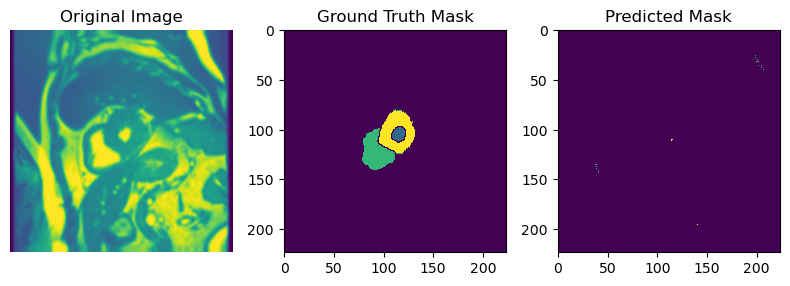

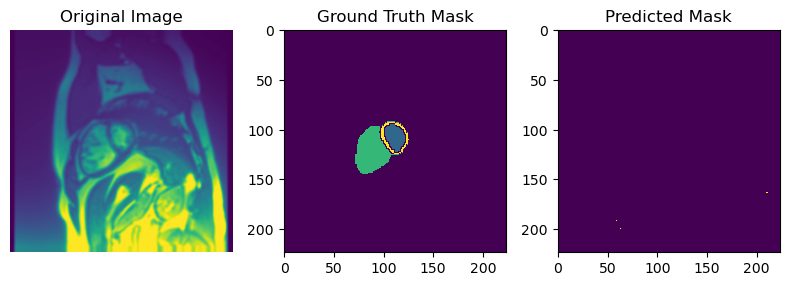

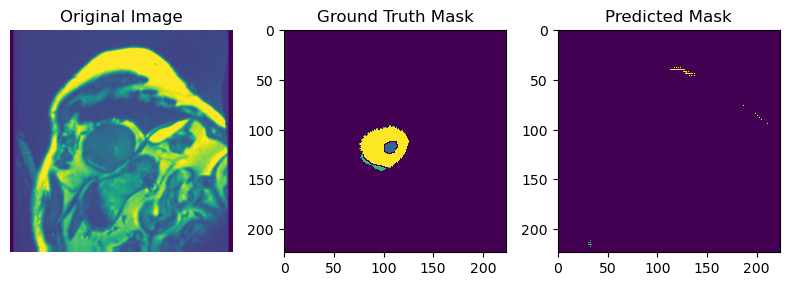

In [13]:
# Assuming you have a DataLoader, model, and device
visualize_predictions(dataloader=test_dataloader, model=model, device=torch.device('cuda'), num_samples=3)

In [ ]:
# torch.cuda.empty_cache()

### Model Evaluation

In [14]:
# Function to calculate Dice score for a single class
def dice_score(pred, target, smooth=1e-6):
    intersection = (pred * target).sum()
    sets_sum = pred.sum() + target.sum()
    sets_sum = torch.where(sets_sum == 0, intersection, sets_sum)
    dice = (2. * intersection + smooth) / (sets_sum + smooth)
    return dice


# Function to evaluate Dice score for each class in the test set
def evaluate_dice_score(model, dataloader, num_classes=4, multi_class=True, device='cpu', threshold=0.5):
    model.eval()  # Set model to evaluation mode
    dice_scores = [0.0] * num_classes  # List to store Dice score for each class
    # count = 0  # Number of samples
    batch_count = len(dataloader) # Number of batches

    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            # Extract data from the sample
            images, true_masks = sample['image'], sample['masks_all'] if multi_class else sample['masks'][:, 1:, :, :]
            images = images.permute(0, 3, 1, 2)

            images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
            true_masks = true_masks.to(device=device, dtype=torch.long)
            true_masks = F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float()

            outputs = model(images)  # Shape: (batch_size, 4, height, width)

            # Binarize outputs based on threshold
            # predictions = (F.sigmoid(outputs) > threshold).float()
            predictions = F.one_hot(outputs.argmax(dim=1), model.n_classes).permute(0, 3, 1, 2).float()


            # Calculate Dice score for each class
            for i in range(num_classes):  # Loop over each class
                dice_scores[i] += dice_coeff(
                    predictions[:, i, :, :].flatten(0, 1),
                    true_masks[:, i, :, :].flatten(0, 1),
                    reduce_batch_first=False
                    )
                '''
                dice_scores[i] += dice_score(
                    predictions[:, i, :, :],
                    true_masks[:, i, :, :]
                    )
                '''

            # count += images.size(0)  # Update sample count
            # batch_count += 1 # Update batch count

    # Average Dice scores across the dataset
    # avg_dice_scores = [score / count for score in dice_scores]
    avg_dice_scores_batch = [score / batch_count for score in dice_scores]
    return avg_dice_scores_batch

In [15]:
# run_id = "f4d2e0deb89f458ca522161566e6e949"

with mlflow.start_run(run_id=run_id):
    # Compute the Dice score for each class in the Train set
    avg_dice_scores_batch = evaluate_dice_score(model, train_dataloader, device=device)
    print("Dice Scores - Train Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)}")
    # print(f"LV: {avg_dice_scores_batch[0]:.4f}\tRV: {avg_dice_scores_batch[1]:.4f}\tMYO: {avg_dice_scores_batch[2]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)}")
    mlflow.log_metric("train_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("train_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("train_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("train_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("train_dice_score", round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)) # avg_dice_scores_batch[1:]


    # Compute the Dice score for each class in the Validation set
    avg_dice_scores_batch = evaluate_dice_score(model, val_dataloader, device=device)
    print("\nDice Scores - Validation Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)}")
    # print(f"LV: {avg_dice_scores_batch[0]:.4f}\tRV: {avg_dice_scores_batch[1]:.4f}\tMYO: {avg_dice_scores_batch[2]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)}")
    mlflow.log_metric("val_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("val_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("val_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("val_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("val_dice_score", round(torch.tensor(avg_dice_scores_batch).mean().item(), 4))


    # Compute the Dice score for each class in the Test set
    avg_dice_scores_batch = evaluate_dice_score(model, test_dataloader, device=device)
    print("\nDice Scores - Test Set:")
    print(f"BKG: {avg_dice_scores_batch[0]:.4f}\tLV: {avg_dice_scores_batch[1]:.4f}\tRV: {avg_dice_scores_batch[2]:.4f}\tMYO: {avg_dice_scores_batch[3]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)}")
    # print(f"LV: {avg_dice_scores_batch[0]:.4f}\tRV: {avg_dice_scores_batch[1]:.4f}\tMYO: {avg_dice_scores_batch[2]:.4f}\tOVR: {round(torch.tensor(avg_dice_scores_batch).mean().item(), 4)}")
    mlflow.log_metric("test_dc_bkg", round(avg_dice_scores_batch[0].item(), 4))
    mlflow.log_metric("test_dc_lv", round(avg_dice_scores_batch[1].item(), 4))
    mlflow.log_metric("test_dc_rv", round(avg_dice_scores_batch[2].item(), 4))
    mlflow.log_metric("test_dc_myo", round(avg_dice_scores_batch[3].item(), 4))
    mlflow.log_metric("test_dice_score", round(torch.tensor(avg_dice_scores_batch).mean().item(), 4))

Dice Scores - Train Set:
BKG: 0.9771	LV: 0.0000	RV: 0.0001	MYO: 0.0001	OVR: 0.0001

Dice Scores - Validation Set:
BKG: 0.9792	LV: 0.0000	RV: 0.0003	MYO: 0.0000	OVR: 0.0001

Dice Scores - Test Set:
BKG: 0.9769	LV: 0.0000	RV: 0.0003	MYO: 0.0000	OVR: 0.0001
